# **Test d'Ipotesi**

In [72]:
import pandas as pd
import numpy as np
import statsmodels as sm
import matplotlib.pyplot as plt 
import seaborn as sns

In [39]:
"""
Supponiamo che il team marketing dell'e-commerce stia valutando dove concentrare il prossimo aumento di budget per le campagne a pagamento. 
Dall'analisi iniziale emerge che il Giappone mostra un conversion rate per l'ultimo anno completo (2025) leggermente superiore rispetto alla Cina, 
ma la differenza è relativamente piccola e non è chiaro se sia dovuta al caso oppure rifletta un reale vantaggio del mercato giapponese.
Il responsabile chiede quindi di verificare in modo rigoroso se questa differenza sia statisticamente significativa, 
così da poter giustificare (o meno) una riallocazione del budget verso il Giappone. 
Per evitare di fare affidamento su ipotesi forti sulla distribuzione dei dati, decidiamo di utilizzare un permutation test sul conversion rate tra Giappone e Corea del Sud, 
confrontando la differenza osservata con quella che otterremmo riassegnando casualmente le etichette di Paese alle sessioni.
"""

"\nSupponiamo che il team marketing dell'e-commerce stia valutando dove concentrare il prossimo aumento di budget per le campagne a pagamento. \nDall'analisi iniziale emerge che il Giappone mostra un conversion rate per l'ultimo anno completo (2025) leggermente superiore rispetto alla Cina, \nma la differenza è relativamente piccola e non è chiaro se sia dovuta al caso oppure rifletta un reale vantaggio del mercato giapponese.\nIl responsabile chiede quindi di verificare in modo rigoroso se questa differenza sia statisticamente significativa, \ncosì da poter giustificare (o meno) una riallocazione del budget verso il Giappone. \nPer evitare di fare affidamento su ipotesi forti sulla distribuzione dei dati, decidiamo di utilizzare un permutation test sul conversion rate tra Giappone e Corea del Sud, \nconfrontando la differenza osservata con quella che otterremmo riassegnando casualmente le etichette di Paese alle sessioni.\n"

In [40]:
""" 
H₀: Sotto l'ipotesi nulla, il conversion rate del Giappone e quello della Corea del Sud sono uguali.  
Qualsiasi differenza osservata è attribuibile al caso.
H₁: Sotto l'ipotesi alternativa, i due Paesi hanno conversion rate diversi.  
La differenza osservata non è compatibile con il caso.
"""

" \nH₀: Sotto l'ipotesi nulla, il conversion rate del Giappone e quello della Corea del Sud sono uguali.  \nQualsiasi differenza osservata è attribuibile al caso.\nH₁: Sotto l'ipotesi alternativa, i due Paesi hanno conversion rate diversi.  \nLa differenza osservata non è compatibile con il caso.\n"

In [ ]:
events_clean=pd.read_csv("..\\f)_data\\clean_data\\events_clean.csv")

In [42]:
# Filtra solo l'anno 2025 
events_2025 = events_clean[events_clean["year"] == 2025].copy()

In [43]:
# Filtriamo i due Paesi
country1 = "Japan"
country2 = "South Korea"
subset = events_2025[events_2025["country"].isin([country1, country2])].copy()

In [44]:
# Creiamo la variabile binaria di conversione e il vettore dei gruppi
subset["converted"] = (subset["event_type"] == "purchase").astype(int)
subset["group"] = subset["country"]

In [45]:
subset["group"].value_counts()

group
South Korea    6835
Japan          3189
Name: count, dtype: int64

In [46]:
# Osserviamo i Conversion rate
cr_japan = subset[subset["country"] == country1]["converted"].mean()
cr_south_korea = subset[subset["country"] == country2]["converted"].mean()

print(f"Conversion rate Giappone: {cr_japan:.4f}")
print(f"Conversion rate Corea del Sud: {cr_south_korea:.4f}")

Conversion rate Giappone: 0.4860
Conversion rate Corea del Sud: 0.4546


In [47]:
# Estraiamo i vettori per il test
y = subset["converted"].values     
g = subset["group"].values          

In [48]:
# Calcoliamo la differenza che useremo come statistica del test:
obs_diff = cr_japan - cr_south_korea
obs_diff

np.float64(0.031473726780724576)

In [49]:
"""
Il permutation test risponderà alla domanda:
"Se rimescolassi a caso le etichette dei paesi, otterrei una differenza così grande o più grande solo per caso?
Se la differenza osservata tra fosse dovuta al caso, 
allora rimescolando casualmente le etichette dovremmo ottenere differenze simili.
"""

'\nIl permutation test risponderà alla domanda:\n"Se rimescolassi a caso le etichette dei paesi, otterrei una differenza così grande o più grande solo per caso?\nSe la differenza osservata tra fosse dovuta al caso, \nallora rimescolando casualmente le etichette dovremmo ottenere differenze simili.\n'

In [50]:
n_permutations = 6000 

# Lista per salvare le differenze permutate 
perm_diffs = [] 

for _ in range(n_permutations): 
    shuffled = np.random.permutation(g)  # rimescolo le etichette 
    cr_g = y[shuffled == country1].mean() 
    cr_c = y[shuffled == country2].mean() 
    perm_diffs.append(cr_g - cr_c) 
    
perm_diffs = np.array(perm_diffs)

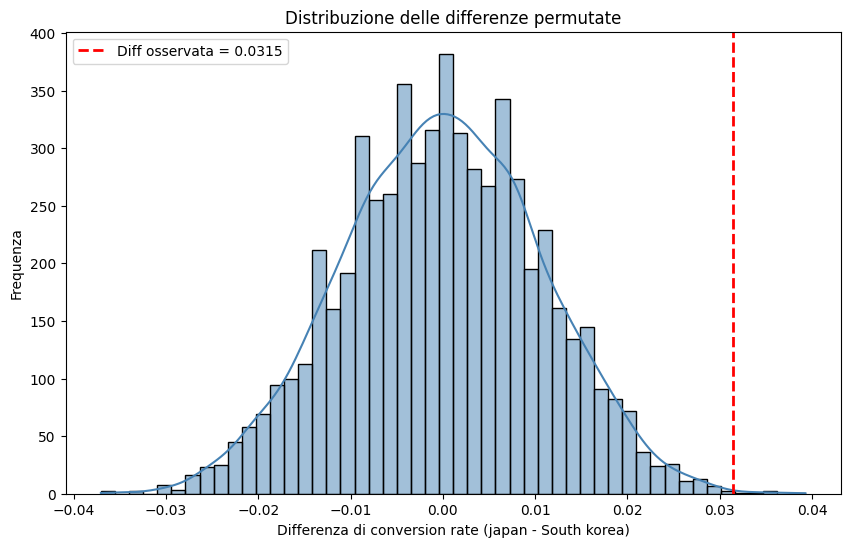

In [51]:
# Visualizziamo la distribuzione delle differenze permutate

plt.figure(figsize=(10,6)) 
sns.histplot(perm_diffs, bins=50, kde=True, color="steelblue")

# Linea della differenza osservata 
plt.axvline(obs_diff, color="red", linestyle="--", linewidth=2, label=f"Diff osservata = {obs_diff:.4f}") 

plt.title("Distribuzione delle differenze permutate") 
plt.xlabel("Differenza di conversion rate (japan - South korea)") 
plt.ylabel("Frequenza") 
plt.legend() 
plt.show()

In [52]:
"""
Osservando la posizione della differenza osservata inizialmente, 
possiamo già dire che la differenza è troppo grande per essere casuale → significativa
"""

'\nOsservando la posizione della differenza osservata inizialmente, \npossiamo già dire che la differenza è troppo grande per essere casuale → significativa\n'

In [53]:
# Calcoliamo il p-value: conta quante differenze permutate sono almeno grandi quanto quella osservata
p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
p_value


np.float64(0.0015)

In [54]:
# Interpretazione del permutation test Germania vs Cina

print(f"Conversion rate Giappone: {cr_japan:.4f}")
print(f"Conversion rate Corea del Sud:     {cr_south_korea:.4f}")
print(f"Differenza osservata:     {obs_diff:.4f}")
print(f"P-value (permutation test): {p_value:.4f}\n")

alpha = 0.05

if p_value < alpha:
    print("Conclusione:")
    print("La differenza osservata tra i conversion rate di Giappone e Corea del Sud è")
    print("statisticamente significativa (p < 0.05).")
    print("È improbabile che una differenza così grande sia dovuta al caso.")
else:
    print("Conclusione:")
    print("La differenza osservata tra i conversion rate di Giappone e Corea del Sud NON è")
    print("statisticamente significativa (p ≥ 0.05).")
    print("La differenza può essere spiegata dalla variabilità casuale delle sessioni.")


Conversion rate Giappone: 0.4860
Conversion rate Corea del Sud:     0.4546
Differenza osservata:     0.0315
P-value (permutation test): 0.0015

Conclusione:
La differenza osservata tra i conversion rate di Giappone e Corea del Sud è
statisticamente significativa (p < 0.05).
È improbabile che una differenza così grande sia dovuta al caso.


In [55]:
"""Cerchiamo di andare oltre. Proviamo a spiegare perchè questo accade"""

'Cerchiamo di andare oltre. Proviamo a spiegare perchè questo accade'

In [ ]:
# Calcoliamo il Conversion Rate per ogni sorgente di traffico
traffic_analysis = subset.groupby(['country', 'traffic_source']).agg(
    totale_sessioni=('session_id', 'count'),
    conversioni=('converted', 'sum')
).reset_index()

traffic_analysis['conversion_rate'] = (traffic_analysis['conversioni'] / traffic_analysis['totale_sessioni']) * 100

# Confrontiamo i risultati
print(traffic_analysis.sort_values(by=['traffic_source', 'country']))

       country traffic_source  totale_sessioni  conversioni  conversion_rate
0        Japan        Adwords              937          458        48.879402
5  South Korea        Adwords             2019          887        43.932640
1        Japan          Email             1462          704        48.153215
6  South Korea          Email             3082         1441        46.755354
2        Japan       Facebook              326          171        52.453988
7  South Korea       Facebook              692          309        44.653179
3        Japan        Organic              140           66        47.142857
8  South Korea        Organic              329          157        47.720365
4        Japan        YouTube              324          151        46.604938
9  South Korea        YouTube              713          313        43.899018


In [ ]:
"""
Con questo si è dimostrato che il Giappone non solo ha convertito meglio in termini assoluti, 
ma lo ha fatto in modo consistente attraverso quasi tutti i canali.
L'unica eccezione è l'organic, ovvero gli utenti che arrivano sul sito senza che ci sia stata un'azione specifica.
Approfondiamo meglio con una regressione logistica.
"""

# **Regressione Logistica**

In [75]:
# Selezioniamo solo le colonne che ci servono
# converted sarà la nostra Y 
# country e traffic_source saranno le nostre X 
df_model_data = subset[['converted', 'country', 'traffic_source']]

print(f"Dimensioni del dataset: {df_model_data.shape[0]} sessioni.")
print(df_model_data['country'].value_counts())

Dimensioni del dataset: 10024 sessioni.
country
South Korea    6835
Japan          3189
Name: count, dtype: int64


In [76]:
# Trasformiamo le categorie in colonne numeriche. drop_first=True eliminerà una categoria per ogni gruppo, usandola come 'base' di confronto
X = pd.get_dummies(df_model_data[['country', 'traffic_source']], drop_first=True, dtype=int)

# La nostra variabile target rimane la stessa
y = df_model_data['converted']

# Aggiungiamo una costante. 
# Senza questa, il modello assumerebbe che se tutte le X sono 0, la probabilità di acquisto sia 0. 
# La costante (intercetta) corregge questo errore.
import statsmodels.api as sm
X = sm.add_constant(X)

print("Esempio delle prime righe della matrice X:")
print(X.head())
# riferimenti: Japan e Adwords

Esempio delle prime righe della matrice X:
     const  country_South Korea  traffic_source_Email  \
462    1.0                    0                     1   
528    1.0                    0                     0   
529    1.0                    0                     0   
569    1.0                    0                     0   
572    1.0                    0                     0   

     traffic_source_Facebook  traffic_source_Organic  traffic_source_YouTube  
462                        0                       0                       0  
528                        1                       0                       0  
529                        0                       0                       0  
569                        1                       0                       0  
572                        0                       0                       0  


In [77]:
# Definiamo il modello Logistico
logit_model = sm.Logit(y, X)
# Addestriamo il modello (fitting)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.690020
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                10024
Model:                          Logit   Df Residuals:                    10018
Method:                           MLE   Df Model:                            5
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:               0.0008933
Time:                        11:44:13   Log-Likelihood:                -6916.8
converged:                       True   LL-Null:                       -6922.9
Covariance Type:            nonrobust   LLR p-value:                   0.03007
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.0945      0.047     -2.004      0.045      -0.187   

In [78]:
np.exp(result.params)

const                      0.909869
country_South Korea        0.881500
traffic_source_Email       1.070372
traffic_source_Facebook    1.068264
traffic_source_Organic     1.088397
traffic_source_YouTube     0.970454
dtype: float64

In [ ]:
"""
Per la Corea abbiamo: P>|z| = 0.003. È un valore bassissimo. 
Ci conferma che la differenza tra Giappone e Corea non è un caso. È una certezza statistica.
osservando l'esponenziale dei parametri notiamo che un utente coreano ha il 12% di probabilità in meno di acquistare rispetto a un giapponese.
Per quanto riguarda i traffic source tutti i P-value delle sorgenti di traffico sono alti.
Significa che in questi due paesi non importa da dove arriva l'utente, il comportamento d'acquisto non cambia significativamente tra i canali.
--> Il problema della Corea non è il marketing (i canali portano traffico simile), ma è qualcosa di strutturale nel mercato coreano.
"""

In [ ]:
"""
l'R quadro è così basso perchè abbiamo usato solo 2 variabili (Paese e Canale) per spiegare una scelta complessa come "comprare o no". 
Il modello ci sta dicendo che non può prevedere esattamente chi comprerà, 
ma ci conferma con assoluta certezza che il Giappone performa meglio della Corea.
"""